**Practical Aspects of Training CNN for Image Classification Task.**

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/AI and ML/FruitinAmazon.zip"
extract_path = "/content/FruitsInAmazon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


**Task - 1:**

In [ ]:
img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    color_mode='rgb',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    color_mode='rgb',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


**Data Augmentation**

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

**Improved CNN (Deeper + BN + Dropout)**

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    layers.Input(shape=(img_height, img_width, 3)),

    # Data Augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Block 4 (deeper model requirement)
    layers.Conv2D(256, (3,3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Fully Connected
    layers.Flatten(),

    layers.Dense(256, activation=None),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.5),

    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 6s/step - accuracy: 0.1944 - loss: 2.2703 - val_accuracy: 0.1667 - val_loss: 11.5036
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.2917 - loss: 1.9159 - val_accuracy: 0.0556 - val_loss: 5.3990
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.5139 - loss: 1.2970 - val_accuracy: 0.4444 - val_loss: 1.6276
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.4861 - loss: 1.3034 - val_accuracy: 0.7222 - val_loss: 0.6215
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.5139 - loss: 1.5493 - val_accuracy: 0.7778 - val_loss: 0.5166
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5972 - loss: 1.0712 - val_accuracy: 0.7778 - val_loss: 0.6622
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.6250 - loss: 0.9905 - val_accuracy: 0.7778 - val_loss: 0.7746
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.6111 - loss: 0.9657 - val_accuracy: 0.6667 - val_loss: 0.9547
Epoch 9

**Image classification via fine-tuning with VGG16**

**1. Load the Pre - trained Model:**

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

**2. Freeze the Layers:**

In [ ]:
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

**3. Add a Custom Layers:**

In [ ]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Get output from base model
x = base_model.output

# Reduce feature maps → single vector per image
x = GlobalAveragePooling2D()(x)

# Fully connected layer
x = Dense(1024, activation='relu')(x)

# Output layer (for classification)
outputs = Dense(num_classes, activation='softmax')(x)

**4. Create the Final Model:**

In [ ]:
from tensorflow.keras.models import Model

# Create final model
model = Model(inputs=base_model.input, outputs=outputs)

**5. Compile and Fit the model.**

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.2639 - loss: 5.2597 - val_accuracy: 0.7778 - val_loss: 0.7681
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 21s/step - accuracy: 0.8750 - loss: 0.6156 - val_accuracy: 0.6667 - val_loss: 1.4319
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 79s 17s/step - accuracy: 0.6944 - loss: 1.8817 - val_accuracy: 0.9444 - val_loss: 0.3073
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 76s 16s/step - accuracy: 0.9722 - loss: 0.1053 - val_accuracy: 0.9444 - val_loss: 0.2988
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 21s/step - accuracy: 0.9583 - loss: 0.1458 - val_accuracy: 0.9444 - val_loss: 0.6186
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 16s/step - accuracy: 0.9861 - loss: 0.0323 - val_accuracy: 0.9444 - val_loss: 1.0874
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 16s/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.8333 - val_loss: 1.5858
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 17s/step - accuracy: 0.9722 - loss: 0.0717 - val_accuracy: 0.8889 - val_loss: 1.5596


**Task 2**

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 54s 17s/step - accuracy: 0.1528 - loss: 8.5718 - val_accuracy: 0.5556 - val_loss: 1.9854
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 16s/step - accuracy: 0.5833 - loss: 2.9367 - val_accuracy: 0.7778 - val_loss: 1.1182
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 17s/step - accuracy: 0.8056 - loss: 1.1101 - val_accuracy: 0.8333 - val_loss: 1.0451
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 21s/step - accuracy: 0.8750 - loss: 0.4941 - val_accuracy: 0.8333 - val_loss: 0.9897
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 21s/step - accuracy: 0.8750 - loss: 0.2335 - val_accuracy: 0.8889 - val_loss: 0.7915
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.9583 - loss: 0.1475 - val_accuracy: 0.8889 - val_loss: 0.9025
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 84s 16s/step - accuracy: 0.9306 - loss: 0.3765 - val_accuracy: 0.8889 - val_loss: 0.8028
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 21s/step - accuracy: 0.9306 - loss: 0.5313 - val_accuracy: 0.9444 - val_loss: 0.6069


In [ ]:
import os

base_path = "/content/FruitsInAmazon/FruitinAmazon"

train_dir = os.path.join(base_path, "train")
test_dir = os.path.join(base_path, "test")

In [ ]:
import tensorflow as tf

rescale = tf.keras.layers.Rescaling(1./255)

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
              precision    recall  f1-score   support

        acai       0.33      0.20      0.25         5
     cupuacu       0.29      1.00      0.45         5
    graviola       0.50      0.40      0.44         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.40      0.40      0.40         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.33        30
   macro avg       0.25      0.33      0.26        30
weighted avg       0.25      0.33      0.26        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


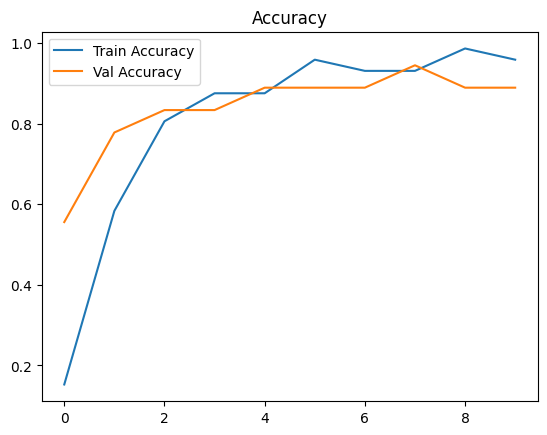

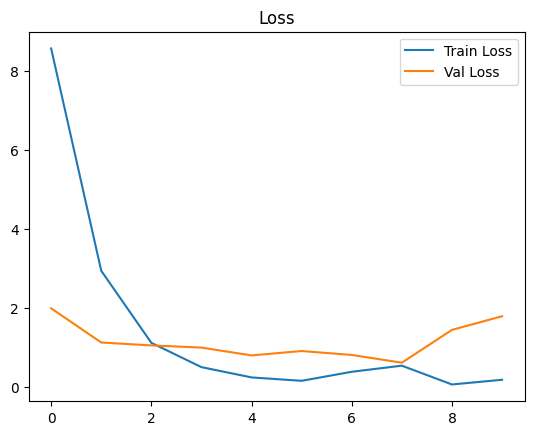

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()